# Chapter 9: Multidimensional Arrays with Xarray

*Part II — Geographic Data Science*

## Learning Objectives

By the end of this chapter you will be able to:

- Work with labeled multidimensional arrays
- Use Xarray for temporal and spatial slicing
- Integrate Xarray with Rasterio and Dask

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

## Introduction to Xarray

Chapter 8's SRTM elevation grid had one band, one moment in time, one variable. Real land-use and climate data rarely stay that simple — a land-cover product tracks several classes at once, across many years, over the same spatial grid. Stack all of that into a single NumPy array and you get a genuinely confusing object: a 4D array of shape `(7, 20, 469, 554)` — which axis is time again, and which is the *forest* class versus *agriculture*?

`xarray`'s `DataArray` solves exactly this by attaching **names and coordinate labels to every dimension**, instead of leaving you to remember that axis 0 means time. The dataset behind this chapter is a real one: land-cover fractions for Brazil, on a 100 km² grid, as used in this book's own LUCC modeling work:

In [2]:
ds = xr.open_dataset("LUCCMEBR_land_cover_type_100km2_2000.nc", decode_times=False)
ds

<xarray.Dataset> Size: 15MB
Dimensions:  (time: 1, lat: 469, lon: 554)
Coordinates:
  * time     (time) float64 8B 0.0
  * lat      (lat) float64 4kB -33.72 -33.63 -33.55 -33.47 ... 5.116 5.2 5.283
  * lon      (lon) float64 4kB -77.49 -77.41 -77.32 ... -31.57 -31.49 -31.41
Data variables:
    crs      int32 4B ...
    veg      (time, lat, lon) float64 2MB ...
    gveg     (time, lat, lon) float64 2MB ...
    pastp    (time, lat, lon) float64 2MB ...
    agric    (time, lat, lon) float64 2MB ...
    mosc     (time, lat, lon) float64 2MB ...
    fores    (time, lat, lon) float64 2MB ...
    others   (time, lat, lon) float64 2MB ...
Attributes:
    CDI:                 Climate Data Interface version 1.9.2 (http://mpimet....
    Conventions:         CF-1.5
    GDAL_AREA_OR_POINT:  Area
    GDAL:                GDAL 2.1.3, released 2017/20/01
    CDO:                 Climate Data Operators version 1.9.2 (http://mpimet....
    NCO:                 netCDF Operators version 4.8.1 (Homepage = http://nc...
    LAND_COVER_TYPE:     veg (Forest vegetation), gveg (Grassland vegetation)...
    history:             Thu Jul 22 16:15:02 2021: ncatted -a history,global,...

That single `xr.open_dataset()` call already reveals more than `rasterio` would about the same file: this is an `xr.Dataset` — a *collection* of `DataArray`s (`veg`, `gveg`, `pastp`, `agric`, `mosc`, `fores`, `others`, one per land-cover class) that all **share the same coordinates**: `time`, `lat`, `lon`. Pull out a single class and you have a `DataArray`, the array-with-labels building block everything else in this chapter builds on:

`decode_times=False` above sidesteps a real gotcha, worth knowing about even though it doesn't matter for this particular file: this dataset's `time` coordinate is stored as `"years since 2000-1-1"`, a unit `xarray`'s built-in date decoder can't handle on its own, since a "year" isn't a fixed duration the way a day or a second is. Resolving it properly needs the optional `cftime` package. Leaving `time` undecoded is harmless here — this file only has a single time step, and nothing below does date arithmetic on it — but a real multi-year dataset would need `cftime` installed (or `decode_times=True` with it available) to get genuine, sortable dates instead of raw numbers on that axis.

In [3]:
forest = ds["veg"]
print(type(forest))
print(forest.dims)     # named axes, in order
print(forest.coords)   # the actual coordinate values along each axis
forest

<class 'xarray.core.dataarray.DataArray'>
('time', 'lat', 'lon')
Coordinates:
  * time     (time) float64 8B 0.0
  * lat      (lat) float64 4kB -33.72 -33.63 -33.55 -33.47 ... 5.116 5.2 5.283
  * lon      (lon) float64 4kB -77.49 -77.41 -77.32 ... -31.57 -31.49 -31.41


<xarray.DataArray 'veg' (time: 1, lat: 469, lon: 554)> Size: 2MB
[259826 values with dtype=float64]
Coordinates:
  * time     (time) float64 8B 0.0
  * lat      (lat) float64 4kB -33.72 -33.63 -33.55 -33.47 ... 5.116 5.2 5.283
  * lon      (lon) float64 4kB -77.49 -77.41 -77.32 ... -31.57 -31.49 -31.41
Attributes:
    long_name:     GDAL Band Number 1
    units:         uso
    grid_mapping:  crs

`forest.dims` reads `('time', 'lat', 'lon')` — no need to remember an axis order by position, the array carries it with it. This is the same idea Chapter 3's `DataFrame` applied to tabular data (a named column instead of a bare column index); `xarray` applies it to a grid with more than two dimensions.

## Temporal and Spatial Slicing

A plain NumPy array only understands **positional** indexing: `arr[0, 230, 300]` selects "whatever happens to be at position 230 along axis 1." `xarray` adds **label-based** indexing on top, through `.sel()` — select by the coordinate's actual value, and let `xarray` work out which position that corresponds to:

In [4]:
# Positional indexing still works, exactly like NumPy (via .isel)
first_timestep = forest.isel(time=0)

# Label-based indexing: select by real coordinate values instead
sao_luis = forest.isel(time=0).sel(lat=-2.53, lon=-44.30, method="nearest")
print("Forest fraction nearest São Luís:", float(sao_luis.values))

Forest fraction nearest São Luís: 0.07875


`method="nearest"` matters here for the same reason Chapter 6's CRS discussion did: `-2.53, -44.30` is very unlikely to land exactly on one of this grid's 100 km² cell centers, so `.sel()` needs permission to snap to the closest one instead of raising a "no exact match" error. Note the explicit `.isel(time=0)` before it, too: `forest` has three dimensions, and `.sel()` only collapses the two it was given (`lat`, `lon`) — without reducing `time` as well, the result keeps a length-1 `time` axis and isn't a true scalar, which `float()` refuses to convert.

Slicing works the same way, with a Python `slice` in place of a single value — select every cell within a bounding box around Maranhão's coast, across every available year, without writing a single explicit loop. One real gotcha: `xarray`'s `slice(low, high)` only works as expected when the underlying coordinate is sorted in *ascending* order — pass it a `lat` axis stored descending (a common convention, north-to-south) and the slice silently returns nothing at all, rather than raising an error. `.sortby("lat")` guarantees the ascending order `slice()` needs, regardless of how the file happened to store it:

('time', 'lat', 'lon') (1, 78, 84)


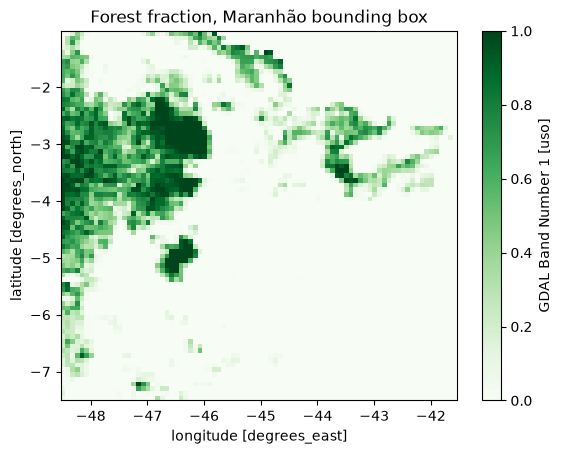

In [5]:
forest_sorted = forest.sortby("lat")  # ensure ascending order, regardless of how the file stored it

maranhao_region = forest_sorted.sel(
    lat=slice(-7.5, -1.0),   # ascending: smallest first, matching sortby above
    lon=slice(-48.5, -41.5),
)
print(maranhao_region.dims, maranhao_region.shape)

maranhao_region.isel(time=0).plot(cmap="Greens")
plt.title("Forest fraction, Maranhão bounding box")
plt.show()

Both slices above stayed a `DataArray` throughout — no intermediate conversion back to a bare NumPy array was ever necessary, and every operation kept its coordinate labels attached, ready for the next `.sel()`, the next plot, or the next arithmetic expression.

## Integrating with rasterio

`xarray` reads NetCDF natively, but Chapter 8's world — GeoTIFFs, CRS objects, `rasterio.warp` reprojection — doesn't disappear. The `rioxarray` package (an extension registered under the `.rio` accessor) bridges the two: it teaches a `DataArray` to carry a real CRS and reproject itself, the same operations Chapter 6 and Chapter 7 did on vector data:

In [6]:
import rioxarray  # noqa: F401 — registers the .rio accessor on DataArray/Dataset

forest_geo = forest.rio.write_crs("EPSG:4326")  # this NetCDF's data is in WGS84
print(forest_geo.rio.crs)

forest_utm = forest_geo.rio.reproject("EPSG:31983")  # SIRGAS 2000 / UTM 23S
print(forest_utm.rio.resolution())  # now in meters, not degrees

EPSG:4326
(9366.31293579506, -9366.31293579506)


Everything downstream of that reprojection — `.sel()`, `.isel()`, plotting — works exactly as before; only the coordinate values and their units changed. `rioxarray` can also open a GeoTIFF directly into a CRS-aware `DataArray` (`rioxarray.open_rasterio(path)`), which makes it a genuine alternative to plain `rasterio` for single-band rasters too, not just NetCDF stacks — the choice mostly comes down to whether you want the labeled-dimension conveniences of `xarray` on top.

## Scaling Up with Dask

`xr.open_dataset()` above loaded the entire file into memory — fine at 469×554 cells, seven variables, twenty-odd years. A continental-scale cube at finer resolution, or a genuinely long time series, stops fitting in memory the same way. `xarray` integrates with **Dask** to handle exactly that case: pass `chunks=` to `open_dataset()`, and instead of loading data immediately, `xarray` builds a lazy, chunked plan — the array's shape, dims, and coordinates are known right away, but the actual numbers aren't read from disk until something forces a computation (a `.plot()`, a `.compute()`, a `print()` of an aggregated value):

<div class="admonition warning">
<p class="admonition-title">Watch out</p>
<p>If <code>dask</code> isn't already installed, <code>pip install dask</code> in a terminal — then <strong>restart the notebook kernel</strong> before re-running the cell below. A running kernel keeps the set of importable packages fixed at the moment it started, so a package installed afterward, in a separate terminal, is invisible to it until it restarts. This is one of the most common "I definitely installed it" errors in notebook-based work.</p>
</div>

In [7]:
ds_lazy = xr.open_dataset("LUCCMEBR_land_cover_type_100km2_2000.nc", chunks={"time": 1}, decode_times=False)
print(ds_lazy["veg"].data)  # a dask.array, not a numpy.ndarray — nothing read from disk yet

# This line triggers the actual computation, one time-chunk at a time
mean_forest_by_year = ds_lazy["veg"].mean(dim=["lat", "lon"]).compute()
mean_forest_by_year

dask.array<open_dataset-veg, shape=(1, 469, 554), dtype=float64, chunksize=(1, 469, 554), chunktype=numpy.ndarray>


<xarray.DataArray 'veg' (time: 1)> Size: 8B
array([0.16927971])
Coordinates:
  * time     (time) float64 8B 0.0
Attributes:
    long_name:     GDAL Band Number 1
    units:         uso
    grid_mapping:  crs

Chunking by `time` here means each year's grid is read, reduced to a single mean, and discarded before the next year is touched — the full multi-year cube is never resident in memory all at once. This is the same underlying trade-off Chapter 17 revisits for simulation performance: process a manageable *tile* or *chunk* at a time, save the result, move on — rather than assuming everything fits in RAM simultaneously. A production land-use data pipeline built on grids far larger than this one leans on precisely this pattern, tile by tile, to stay within memory limits no matter how large the full study area grows.

## Exercises

1. **Explore the Dataset.** Print `ds.data_vars` and `ds["agric"].attrs`. What unit does the `units` attribute claim for these land-cover fractions, and does that match what you'd expect from a fraction of a 100 km² cell?
2. **A different class, a different slice.** Repeat the *Temporal and Spatial Slicing* bounding-box example for `ds["agric"]` (agriculture) instead of `ds["veg"]` (forest). Does agricultural cover look concentrated in the same region as forest, or somewhere else?
3. **Time-average correctly.** Compute the *time*-averaged forest fraction at every grid cell (`forest.mean(dim="time")`) and plot it. How is this different from `mean_forest_by_year`, which averaged over *space* instead?
4. **Chunk by a different dimension.** Reopen the dataset with `chunks={"lat": 100}` instead of `chunks={"time": 1}`. Does `ds_lazy["veg"].mean(dim=["lat", "lon"]).compute()` still give the same answer? Should it?

In [8]:
# Your code here

## Summary

### Key concepts introduced

- `xr.DataArray`: a NumPy array with named dimensions and real coordinate values attached to every axis, instead of a bare position
- `xr.Dataset`: a collection of `DataArray`s sharing the same coordinates — one per land-cover class here, one per satellite band or model variable elsewhere
- `.isel()` for positional indexing and `.sel()` for label-based indexing, including `method="nearest"` and slicing by real-world coordinate ranges
- `rioxarray` and the `.rio` accessor, bridging `xarray`'s labeled arrays with Chapter 8's CRS and reprojection tools
- Chunked, lazy loading with Dask (`chunks=`), and why processing a cube tile by tile — never holding the whole thing in memory — is the pattern that lets these techniques scale past a single machine's RAM

Chapter 10 returns to vector data, but asks a different kind of question about it: not *what value is at this location*, but *which locations count as neighbors of which*.

## Further Reading

- xarray documentation, *Why xarray?*: <https://docs.xarray.dev/en/stable/getting-started-guide/why-xarray.html>
- rioxarray documentation, *Getting Started*: <https://corteva.github.io/rioxarray/stable/getting_started/getting_started.html>
- Dask documentation, *Dask Arrays*: <https://docs.dask.org/en/stable/array.html>
- CF Conventions — the metadata standard behind NetCDF's `units`, `standard_name`, and coordinate attributes: <https://cfconventions.org/>